   user_id artwork  clicked
0        1       A        0
1        2       B        0
2        3       B        1
3        4       B        0
4        5       A        1
5        6       A        0
6        7       A        0
7        8       B        1
8        9       B        0
9       10       B        0

--- Group Summary ---
         users  total_clicks  click_rate
artwork                                 
A          503           127      0.2525
B          497           158      0.3179
        A/B TEST RESULTS SUMMARY
Metric                  Artwork A  Artwork B
---------------------------------------------
Total Users                   503        497
Total Clicks                  127        158
Click-Through Rate         25.25%     31.79%

  Relative lift of B over A: +25.9%


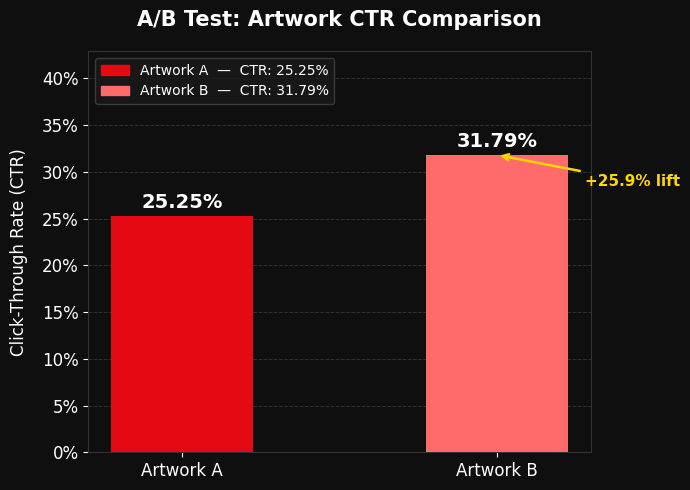


Chart saved as 'artwork_ctr_comparison.png'
        A/B TEST RESULTS SUMMARY
Metric                  Artwork A  Artwork B
---------------------------------------------
Total Users                   503        497
Total Clicks                  127        158
Click-Through Rate         25.25%     31.79%

  Relative lift of B over A: +25.9%

       STATISTICAL TEST RESULTS
  Pooled proportion:           0.2850
  Standard error:              0.0286
  Z-score:                     2.2907
  P-value:                     0.0220
  95% CI for difference:       [0.0096, 0.1212]
  Significance level:          0.05
---------------------------------------------
  ✅ SIGNIFICANT — p=0.0220 < 0.05
  The difference is unlikely due to chance.


/tmp/ipykernel_18956/1319225220.py:310: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18956/1319225220.py:311: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('artwork_ab_test_full.png', dpi=150, bbox_inches='tight',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


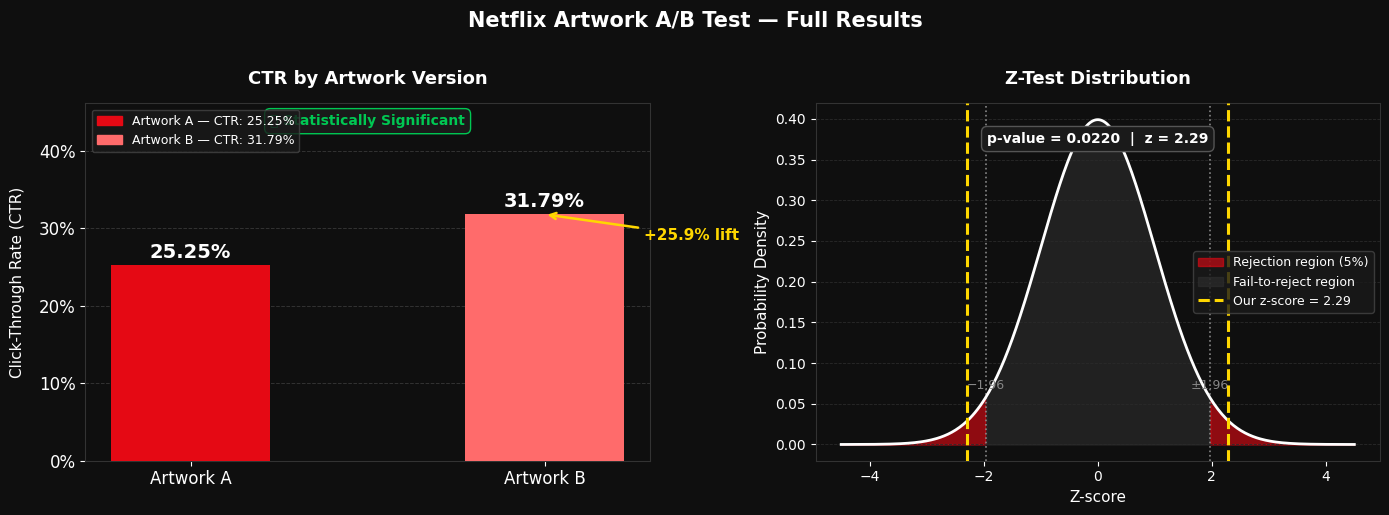


Chart saved as 'artwork_ab_test_full.png'


In [ ]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# --- Experiment Parameters ---
n_users = 1000
prob_A = 0.24  # Click probability for Artwork A
prob_B = 0.30  # Click probability for Artwork B

# --- Step 1: Assign users to groups ---
user_ids = np.arange(1, n_users + 1)
assignments = np.random.choice(['A', 'B'], size=n_users, p=[0.5, 0.5])

# --- Step 2: Simulate clicks based on assigned artwork ---
clicks = np.where(
    assignments == 'A',
    np.random.binomial(1, prob_A, size=n_users),
    np.random.binomial(1, prob_B, size=n_users)
)

# --- Step 3: Build the DataFrame ---
df = pd.DataFrame({
    'user_id':   user_ids,
    'artwork':   assignments,
    'clicked':   clicks
})

# --- Step 4: Quick sanity check ---
summary = df.groupby('artwork')['clicked'].agg(
    users='count',
    total_clicks='sum',
    click_rate='mean'
).round(4)

print(df.head(10))
print("\n--- Group Summary ---")
print(summary)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Experiment Parameters ──────────────────────────────────────────────────────
np.random.seed(42)
n_users  = 1000
prob_A   = 0.24
prob_B   = 0.30

# ── Step 1: Assign users & simulate clicks ────────────────────────────────────
user_ids    = np.arange(1, n_users + 1)
assignments = np.random.choice(['A', 'B'], size=n_users, p=[0.5, 0.5])
clicks      = np.where(
    assignments == 'A',
    np.random.binomial(1, prob_A, size=n_users),
    np.random.binomial(1, prob_B, size=n_users)
)

df = pd.DataFrame({'user_id': user_ids, 'artwork': assignments, 'clicked': clicks})

# ── Step 2: Group-level metrics ───────────────────────────────────────────────
summary = df.groupby('artwork')['clicked'].agg(
    total_users  = 'count',
    total_clicks = 'sum',
    ctr          = 'mean'
).round(4)

print("=" * 45)
print("        A/B TEST RESULTS SUMMARY")
print("=" * 45)
print(f"{'Metric':<22} {'Artwork A':>10} {'Artwork B':>10}")
print("-" * 45)
print(f"{'Total Users':<22} {summary.loc['A','total_users']:>10} {summary.loc['B','total_users']:>10}")
print(f"{'Total Clicks':<22} {summary.loc['A','total_clicks']:>10} {summary.loc['B','total_clicks']:>10}")
print(f"{'Click-Through Rate':<22} {summary.loc['A','ctr']:>10.2%} {summary.loc['B','ctr']:>10.2%}")
print("=" * 45)

lift = (summary.loc['B','ctr'] - summary.loc['A','ctr']) / summary.loc['A','ctr'] * 100
print(f"\n  Relative lift of B over A: +{lift:.1f}%")
print("=" * 45)

# ── Step 3: Bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#0F0F0F')

artworks = ['Artwork A', 'Artwork B']
ctrs     = [summary.loc['A', 'ctr'], summary.loc['B', 'ctr']]
colors   = ['#E50914', '#FF6B6B']          # Netflix-red palette
bars     = ax.bar(artworks, ctrs, color=colors, width=0.45, zorder=3)

# Value labels on bars
for bar, val in zip(bars, ctrs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.004,
        f'{val:.2%}',
        ha='center', va='bottom',
        fontsize=14, fontweight='bold', color='white'
    )

# Lift annotation arrow
ax.annotate(
    f'+{lift:.1f}% lift',
    xy=(1, ctrs[1]), xytext=(1.28, (ctrs[0] + ctrs[1]) / 2),
    fontsize=11, color='#FFD700', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1.8)
)

# Styling
ax.set_ylim(0, max(ctrs) * 1.35)
ax.set_ylabel('Click-Through Rate (CTR)', color='white', fontsize=12, labelpad=10)
ax.set_title('A/B Test: Artwork CTR Comparison', color='white', fontsize=15,
             fontweight='bold', pad=18)
ax.tick_params(colors='white', labelsize=12)
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.yaxis.grid(True, color='#333333', linestyle='--', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

legend_patches = [
    mpatches.Patch(color='#E50914', label=f'Artwork A  —  CTR: {ctrs[0]:.2%}'),
    mpatches.Patch(color='#FF6B6B', label=f'Artwork B  —  CTR: {ctrs[1]:.2%}')
]
ax.legend(handles=legend_patches, facecolor='#1A1A1A', edgecolor='#444444',
          labelcolor='white', fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('artwork_ctr_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("\nChart saved as 'artwork_ctr_comparison.png'")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.stats import norm

# ── Experiment Parameters ──────────────────────────────────────────────────────
np.random.seed(42)
n_users  = 1000
prob_A   = 0.24
prob_B   = 0.30

# ── Step 1: Assign users & simulate clicks ────────────────────────────────────
user_ids    = np.arange(1, n_users + 1)
assignments = np.random.choice(['A', 'B'], size=n_users, p=[0.5, 0.5])
clicks      = np.where(
    assignments == 'A',
    np.random.binomial(1, prob_A, size=n_users),
    np.random.binomial(1, prob_B, size=n_users)
)

df = pd.DataFrame({'user_id': user_ids, 'artwork': assignments, 'clicked': clicks})

# ── Step 2: Group-level metrics ───────────────────────────────────────────────
summary = df.groupby('artwork')['clicked'].agg(
    total_users  = 'count',
    total_clicks = 'sum',
    ctr          = 'mean'
).round(4)

n_A      = summary.loc['A', 'total_users']
n_B      = summary.loc['B', 'total_users']
clicks_A = summary.loc['A', 'total_clicks']
clicks_B = summary.loc['B', 'total_clicks']
ctr_A    = summary.loc['A', 'ctr']
ctr_B    = summary.loc['B', 'ctr']
lift     = (ctr_B - ctr_A) / ctr_A * 100

print("=" * 45)
print("        A/B TEST RESULTS SUMMARY")
print("=" * 45)
print(f"{'Metric':<22} {'Artwork A':>10} {'Artwork B':>10}")
print("-" * 45)
print(f"{'Total Users':<22} {n_A:>10} {n_B:>10}")
print(f"{'Total Clicks':<22} {clicks_A:>10} {clicks_B:>10}")
print(f"{'Click-Through Rate':<22} {ctr_A:>10.2%} {ctr_B:>10.2%}")
print("=" * 45)
print(f"\n  Relative lift of B over A: +{lift:.1f}%")
print("=" * 45)

# ── Step 3: Two-Proportion Z-Test ─────────────────────────────────────────────
# Pooled proportion under the null hypothesis (no real difference)
p_pool = (clicks_A + clicks_B) / (n_A + n_B)

# Standard error of the difference between two proportions
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))

# Z-score: how many standard errors apart are the two CTRs?
z_score = (ctr_B - ctr_A) / se

# Two-tailed p-value
p_value = 2 * (1 - norm.cdf(abs(z_score)))

# 95% Confidence interval for the difference (no pooling for CI)
se_ci      = np.sqrt((ctr_A*(1-ctr_A)/n_A) + (ctr_B*(1-ctr_B)/n_B))
diff       = ctr_B - ctr_A
ci_lower   = diff - 1.96 * se_ci
ci_upper   = diff + 1.96 * se_ci
alpha      = 0.05
significant = p_value < alpha

print("\n" + "=" * 45)
print("       STATISTICAL TEST RESULTS")
print("=" * 45)
print(f"  {'Pooled proportion:':<28} {p_pool:.4f}")
print(f"  {'Standard error:':<28} {se:.4f}")
print(f"  {'Z-score:':<28} {z_score:.4f}")
print(f"  {'P-value:':<28} {p_value:.4f}")
print(f"  {'95% CI for difference:':<28} [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"  {'Significance level:':<28} {alpha}")
print("-" * 45)
if significant:
    print(f"  ✅ SIGNIFICANT — p={p_value:.4f} < {alpha}")
    print("  The difference is unlikely due to chance.")
else:
    print(f"  ❌ NOT SIGNIFICANT — p={p_value:.4f} ≥ {alpha}")
    print("  The difference may be due to chance.")
print("=" * 45)

# ── Step 4: Bar chart with significance badge ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0F0F0F')

# ── Left panel: CTR bar chart ──────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#0F0F0F')
artworks = ['Artwork A', 'Artwork B']
ctrs     = [ctr_A, ctr_B]
colors   = ['#E50914', '#FF6B6B']
bars     = ax.bar(artworks, ctrs, color=colors, width=0.45, zorder=3)

for bar, val in zip(bars, ctrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{val:.2%}', ha='center', va='bottom',
            fontsize=14, fontweight='bold', color='white')

ax.annotate(f'+{lift:.1f}% lift',
    xy=(1, ctrs[1]), xytext=(1.28, (ctrs[0]+ctrs[1])/2),
    fontsize=11, color='#FFD700', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1.8))

sig_label = "✅ Statistically Significant" if significant else "❌ Not Significant"
sig_color = '#00C853' if significant else '#FF1744'
ax.text(0.5, 0.97, sig_label, transform=ax.transAxes, ha='center', va='top',
        fontsize=10, color=sig_color, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#1A1A1A', edgecolor=sig_color))

ax.set_ylim(0, max(ctrs) * 1.45)
ax.set_ylabel('Click-Through Rate (CTR)', color='white', fontsize=11, labelpad=10)
ax.set_title('CTR by Artwork Version', color='white', fontsize=13, fontweight='bold', pad=14)
ax.tick_params(colors='white', labelsize=12)
for spine in ax.spines.values(): spine.set_edgecolor('#333333')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.yaxis.grid(True, color='#333333', linestyle='--', linewidth=0.7, zorder=0)
legend_patches = [
    mpatches.Patch(color='#E50914', label=f'Artwork A — CTR: {ctr_A:.2%}'),
    mpatches.Patch(color='#FF6B6B', label=f'Artwork B — CTR: {ctr_B:.2%}')
]
ax.legend(handles=legend_patches, facecolor='#1A1A1A', edgecolor='#444444',
          labelcolor='white', fontsize=9, loc='upper left')

# ── Right panel: Normal distribution + p-value ────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#0F0F0F')

x = np.linspace(-4.5, 4.5, 400)
y = norm.pdf(x)
ax2.plot(x, y, color='white', linewidth=2, zorder=3)
ax2.fill_between(x, y, where=(x <= -1.96), color='#E50914', alpha=0.6,
                 label='Rejection region (5%)')
ax2.fill_between(x, y, where=(x >=  1.96), color='#E50914', alpha=0.6)
ax2.fill_between(x, y, where=((x > -1.96) & (x < 1.96)),
                 color='#333333', alpha=0.5, label='Fail-to-reject region')
ax2.axvline(z_score, color='#FFD700', linewidth=2.2, linestyle='--',
            label=f'Our z-score = {z_score:.2f}', zorder=4)
ax2.axvline(-z_score, color='#FFD700', linewidth=2.2, linestyle='--', zorder=4)
ax2.axvline( 1.96, color='#888888', linewidth=1.2, linestyle=':')
ax2.axvline(-1.96, color='#888888', linewidth=1.2, linestyle=':')

ax2.text( 1.96, norm.pdf(1.96) + 0.01, '±1.96', color='#888888',
         fontsize=9, ha='center')
ax2.text(-1.96, norm.pdf(1.96) + 0.01, '−1.96', color='#888888',
         fontsize=9, ha='center')

p_display = "<0.0001" if p_value < 0.0001 else f"{p_value:.4f}"
ax2.text(0.5, 0.92,
         f'p-value = {p_display}  |  z = {z_score:.2f}',
         transform=ax2.transAxes, ha='center', va='top',
         fontsize=10, color='white', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1A1A1A', edgecolor='#555555'))

ax2.set_title('Z-Test Distribution', color='white', fontsize=13,
              fontweight='bold', pad=14)
ax2.set_xlabel('Z-score', color='white', fontsize=11)
ax2.set_ylabel('Probability Density', color='white', fontsize=11)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#333333')
ax2.legend(facecolor='#1A1A1A', edgecolor='#444444', labelcolor='white', fontsize=9)
ax2.yaxis.grid(True, color='#2A2A2A', linestyle='--', linewidth=0.6)

plt.suptitle('Netflix Artwork A/B Test — Full Results', color='white',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('artwork_ab_test_full.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("\nChart saved as 'artwork_ab_test_full.png'")